<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/41_DecisionTree_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder

from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score

In [20]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/Social_Network_Ads.csv")

In [21]:
df.drop(columns=["User ID"], inplace=True)

In [22]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [23]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]
X

,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000
...,...,...,...
395,Female,46,41000
396,Male,51,23000
397,Female,50,20000
398,Male,36,33000


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [25]:
X_train

,Gender,Age,EstimatedSalary
388,Male,47,34000
372,Female,39,73000
295,Female,36,63000
142,Male,35,59000
217,Male,40,78000
...,...,...,...
199,Male,35,22000
239,Female,53,143000
200,Male,35,39000
124,Female,41,51000


In [26]:
columntrans=ColumnTransformer(
    transformers=[
        ("trf2", StandardScaler(),["Age","EstimatedSalary"]),
        ("trf3", OneHotEncoder(drop="first", sparse_output=False), ["Gender"])
    ]
    ,remainder="passthrough"
    )

In [27]:
X_trains_trf=columntrans.fit_transform(X_train)
X_test_trf=columntrans.transform(X_test)

In [28]:
df1=pd.DataFrame(X_trains_trf,columns=["Age","EstimatedSalary","Gender"])
df1

,Age,EstimatedSalary,Gender
0,0.883119,-1.027623,1.0
1,0.132028,0.105204,0.0
2,-0.149631,-0.185264,0.0
3,-0.243518,-0.301452,1.0
4,0.225914,0.250438,1.0
...,...,...,...
315,-0.243518,-1.376185,1.0
316,1.446437,2.138483,0.0
317,-0.243518,-0.882389,1.0
318,0.319800,-0.533826,0.0


In [29]:
clf=DecisionTreeClassifier(max_depth=None)
clf.fit(X_trains_trf,y_train)

DecisionTreeClassifier()

In [30]:
accuracy_score(y_test,clf.predict(X_test_trf))

0.8625

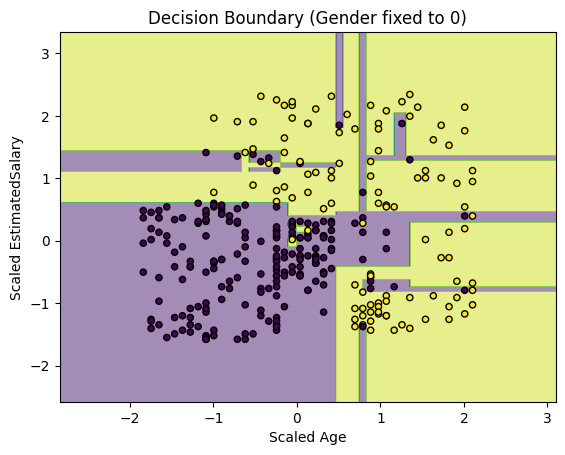

In [34]:
x_min, x_max = X_trains_trf[:, 0].min() - 1, X_trains_trf[:, 0].max() + 1
y_min, y_max = X_trains_trf[:, 1].min() - 1, X_trains_trf[:, 1].max() + 1
XX_2d, YY_2d = np.meshgrid(np.arange(x_min, x_max, 0.01),
                        np.arange(y_min, y_max, 0.01))

input_array_2d = np.c_[XX_2d.ravel(), YY_2d.ravel(), np.full(XX_2d.size, 0)]

# Predict labels for this new 2D input array
Z_pred_2d = clf.predict(input_array_2d)

# Reshape the predictions back to the 2D grid shape
Z_pred_2d = Z_pred_2d.reshape(XX_2d.shape)

# Now, plot the 2D contour
plt.contourf(XX_2d, YY_2d, Z_pred_2d, alpha=0.5)

# Optionally, plot the training data points for context
plt.scatter(X_trains_trf[:, 0], X_trains_trf[:, 1], c=y_train, s=20, edgecolors='k')
plt.xlim(XX_2d.min(), XX_2d.max())
plt.ylim(YY_2d.min(), YY_2d.max())
plt.title('Decision Boundary (Gender fixed to 0)')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled EstimatedSalary')
plt.show()

In [32]:
def analysize(max_depth,X_trains_trf,y_train):

  clf=DecisionTreeClassifier(max_depth=max_depth)
  clf.fit(X_trains_trf,y_train)

  x_min, x_max = X_trains_trf[:, 0].min() - 1, X_trains_trf[:, 0].max() + 1
  y_min, y_max = X_trains_trf[:, 1].min() - 1, X_trains_trf[:, 1].max() + 1
  XX_2d, YY_2d = np.meshgrid(np.arange(x_min, x_max, 0.01),
                           np.arange(y_min, y_max, 0.01))

  input_array_2d = np.c_[XX_2d.ravel(), YY_2d.ravel(), np.full(XX_2d.size, 0)]

  # Predict labels for this new 2D input array
  Z_pred_2d = clf.predict(input_array_2d)

  # Reshape the predictions back to the 2D grid shape
  Z_pred_2d = Z_pred_2d.reshape(XX_2d.shape)

  # Now, plot the 2D contour
  plt.contourf(XX_2d, YY_2d, Z_pred_2d, alpha=0.5)

  # Optionally, plot the training data points for context
  plt.scatter(X_trains_trf[:, 0], X_trains_trf[:, 1], c=y_train, s=20, edgecolors='k')
  plt.xlim(XX_2d.min(), XX_2d.max())
  plt.ylim(YY_2d.min(), YY_2d.max())
  plt.title('Decision Boundary (Gender fixed to 0)')
  plt.xlabel('Scaled Age')
  plt.ylabel('Scaled EstimatedSalary')
  plt.show()

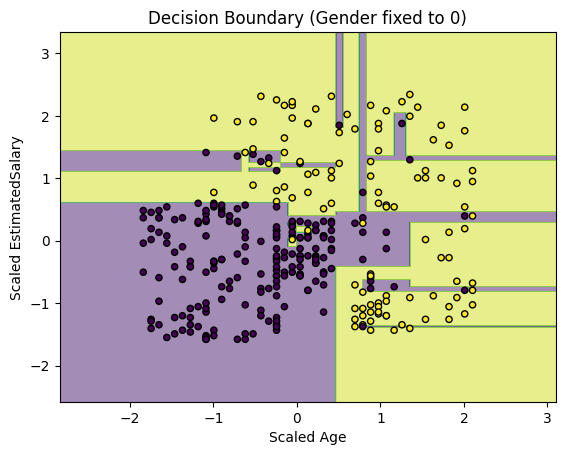

In [33]:
analysize(None,X_trains_trf,y_train)

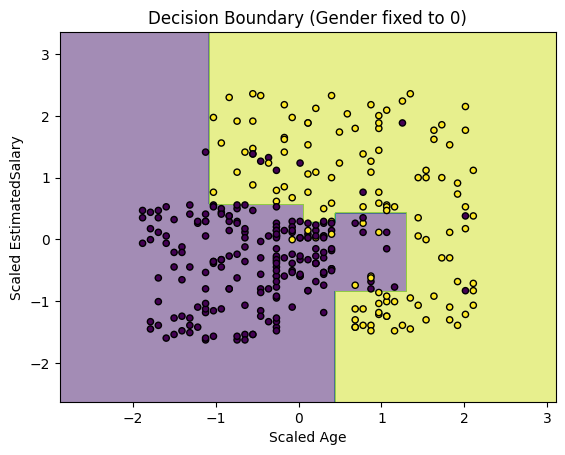

In [ ]:
analysize(4,X_trains_trf,y_train)

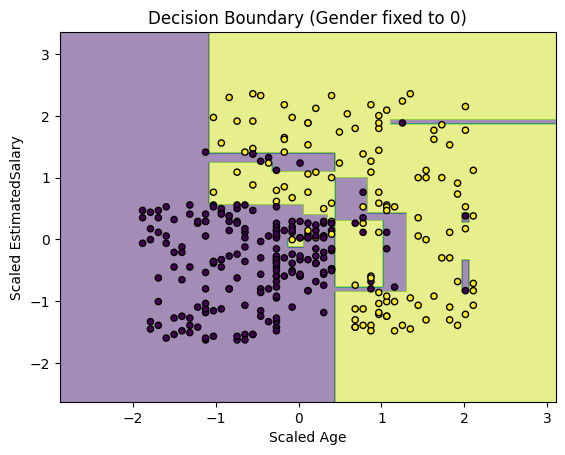

In [ ]:
analysize(8,X_trains_trf,y_train)